# Group 7 — Science Communication Channels and Public Trust: Analysis Notebook

**Rendered companion** to the canonical script at [`code/analysis.py`](../code/analysis.py).
All statistical logic lives in that module — this notebook imports from it and adds
sequential, visible output plus inline figure display.
A grader opening this file on GitHub should see results without running any code.

**Dataset:** TISP (Mede, Cologna et al., 2025, *Scientific Data* 12:114) —
N = 71,922 respondents, 68 countries, Nov 2022–Aug 2023.
**World Bank income-group vintage:** FY2023 (effective 1 July 2022, based on 2021 GNI per capita).


In [1]:
import os, sys

# --- Path setup ---
# This notebook lives in notebooks/, one level below the repo root.
# We chdir to the repo root so that relative paths used in analysis.py
# (e.g. "data/raw/ds_main.csv", "figures/") resolve correctly.
repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
os.chdir(repo_root)
code_dir = os.path.join(repo_root, "code")
if code_dir not in sys.path:
    sys.path.insert(0, code_dir)

# --- Imports from canonical analysis script ---
from analysis import (
    load, multilevel_model, sem_mediation,
    choropleth, anova_by_channel, descriptives_by_income,
)

import matplotlib.pyplot as plt
from IPython.display import Image, display
import plotly.express as px

print("Imports OK. Working directory:", os.getcwd())


Imports OK. Working directory: C:\Users\USER\Documents\github-second-quarter-\science-communication-analysis


## Data Loading

Load `data/raw/ds_main.csv` (delimiter `;`, UTF-8-SIG encoding), replace sentinel
value −99 with NaN, derive composite scores for trust (12-item mean), communication
frequency (10-item mean), and primary channel (argmax), and assign World Bank FY2023
income groups from the hard-coded lookup in `analysis.py`.


In [2]:
df = load("data/raw/ds_main.csv")
print(f"\nPrimary channel distribution:\n{df['primary_channel'].value_counts().to_string()}")
print(f"\nCountry income group distribution:\n{df['country_income_group'].value_counts().to_string()}")


Total rows loaded: 71922
Analytic sample (non-missing trust/comm_freq/knowledge): 71883
Countries represented: 68

Primary channel distribution:
primary_channel
Newspapers             21497
Television             17585
Online News Sites      10960
Other                   8633
Social Media            8057
Family/Friends          3736
Scientific Journals     1415

Country income group distribution:
country_income_group
high_income            47493
upper_middle_income    13098
lower_middle_income     9918
low_income              1374


## 1. Multi-level Regression + ICC

Model: `trust ~ comm_freq + knowledge` with a random intercept for country,
estimated by REML (statsmodels `MixedLM`).
The intraclass correlation coefficient (ICC) = country-level variance /
(country-level variance + residual variance).


In [3]:
mlm_result, icc = multilevel_model(df)



=== Multi-level model (trust ~ comm_freq + knowledge, random intercept: country) ===
          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: trust      
No. Observations: 71883   Method:             REML       
No. Groups:       68      Scale:              0.3408     
Min. group size:  325     Log-Likelihood:     -63477.9138
Max. group size:  8127    Converged:          Yes        
Mean group size:  1057.1                                 
----------------------------------------------------------
           Coef.  Std.Err.     z     P>|z|  [0.025  0.975]
----------------------------------------------------------
Intercept  2.058     0.027   77.107  0.000   2.005   2.110
comm_freq  0.067     0.002   38.225  0.000   0.064   0.071
knowledge  0.317     0.002  133.603  0.000   0.313   0.322
Group Var  0.040     0.012                                


ICC (country-level variance share) = 0.105


## 2. SEM Mediation: comm_freq → knowledge → trust

Tests the two-path mediation model:
- Path a: `knowledge ~ comm_freq`
- Path b: `trust ~ knowledge`
- Direct: `trust ~ comm_freq` (c′)
- Indirect: a × b

Estimated via `semopy` OLS-based SEM.


In [4]:
sem_out = sem_mediation(df)



=== SEM mediation (comm_freq -> knowledge -> trust) ===
        lval  op       rval  Estimate  Std. Err     z-value  p-value
0  knowledge   ~  comm_freq  0.139183  0.002647   52.586073      0.0
1      trust   ~  knowledge  0.325070  0.002456  132.367349      0.0
2      trust   ~  comm_freq  0.070161  0.001776   39.506999      0.0
3  knowledge  ~~  knowledge  0.867914  0.004578  189.582436      0.0
4      trust  ~~      trust  0.376266  0.001985  189.582436      0.0

Path a (comm_freq->knowledge) = 0.1392
Path b (knowledge->trust)     = 0.3251
Direct effect c'              = 0.0702
Indirect effect a*b           = 0.0452
Total effect                  = 0.1154


## 3. Choropleth — Mean Trust in Scientists by Country

Colour scale: Red–Yellow–Blue (RdYlBu). Darker red = lower trust; darker blue = higher trust.
The interactive HTML is also saved to `figures/trust_choropleth.html`.


In [5]:
country_means = choropleth(df, out_html="figures/trust_choropleth.html")

# Display the map inline (plotly renders in Jupyter without needing a browser)
fig_choro = px.choropleth(
    country_means,
    locations="country",
    color="mean_trust",
    color_continuous_scale="RdYlBu",
    locationmode="ISO-3",
    title="Mean Trust in Scientists by Country (TISP, N=71,922, 68 Countries)",
    labels={"mean_trust": "Mean Trust (1–5)"},
)
fig_choro.show()



Choropleth written to figures/trust_choropleth.html

Top 10 highest-trust countries:
country  mean_trust
    IND    4.240372
    EGY    4.130830
    NGA    3.950466
    AUS    3.939915
    NZL    3.925948
    BGD    3.916208
    TUR    3.890174
    ESP    3.889319
    MEX    3.884478
    GHA    3.882218

Bottom 10 lowest-trust countries:
country  mean_trust
    KAZ    3.147596
    ALB    3.161569
    BOL    3.183867
    RUS    3.225681
    ISR    3.368757
    JPN    3.369771
    GRC    3.379227
    CMR    3.387954
    UKR    3.388905
    TWN    3.394888


## 4. One-way ANOVA — Trust by Primary Communication Channel

Tests whether mean trust in scientists differs across the seven primary
communication channel groups. Boxplot also saved to `figures/anova_channel_boxplot.png`.



=== One-way ANOVA: trust ~ primary_channel ===
F = 27.963, p = 1.462e-33

Group means:
                         mean  count
primary_channel                     
Family/Friends       3.565347   3736
Newspapers           3.665038  21497
Online News Sites    3.606484  10960
Other                3.612152   8633
Scientific Journals  3.597087   1415
Social Media         3.578527   8057
Television           3.651938  17585


Boxplot saved to figures/anova_channel_boxplot.png


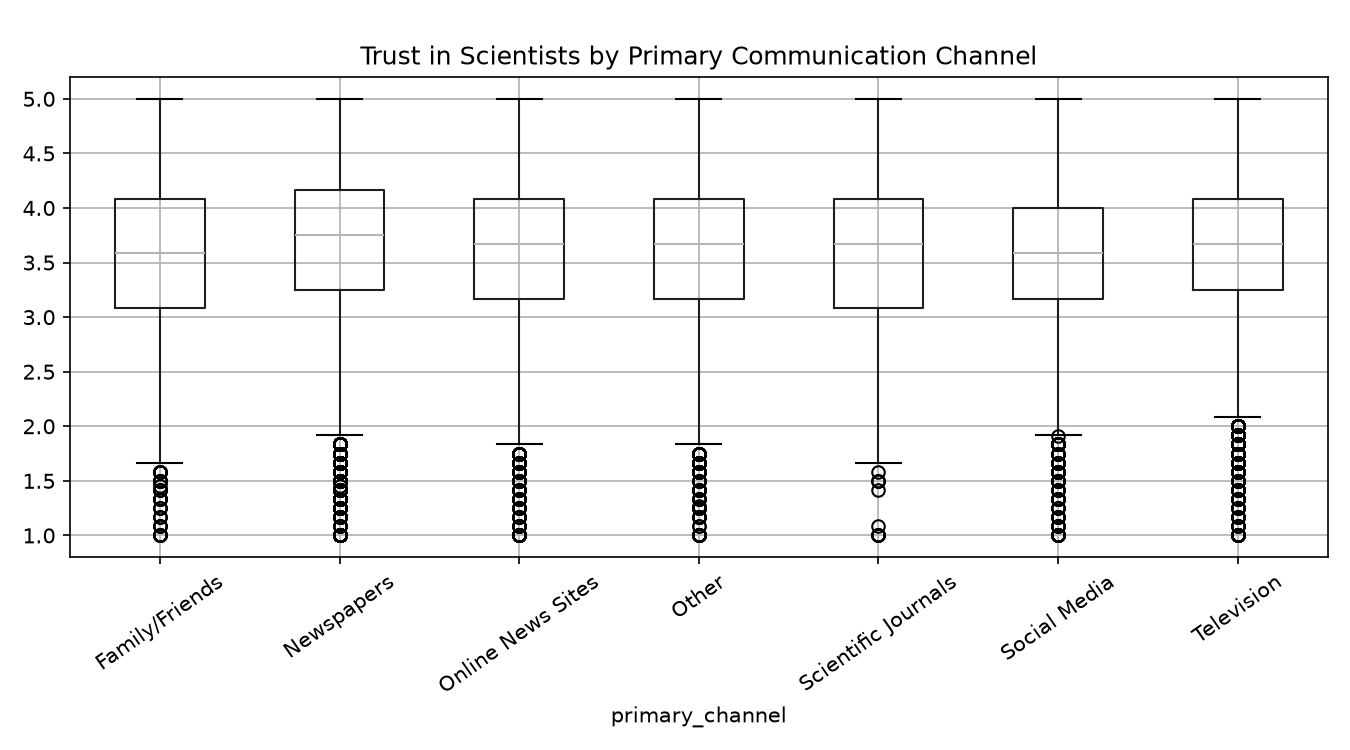

In [6]:
f_stat, p_val = anova_by_channel(df)

# Display the saved boxplot inline
# (analysis.py uses the Agg backend, so we display from the saved file)
plt.close("all")
display(Image("figures/anova_channel_boxplot.png"))


## Descriptive Table — Trust by Country Income Group (Table 1)

Uses World Bank FY2023 income classifications for all 68 countries.
Full CSV saved to `figures/table1_descriptives.csv`.


In [7]:
tbl = descriptives_by_income(df)



=== Table 1 - Trust descriptives by country income group ===
                        count   mean    std  min    25%    50%    75%  max
country_income_group                                                      
high_income           47493.0  3.615  0.676  1.0  3.167  3.667  4.083  5.0
low_income             1374.0  3.613  0.755  1.0  3.167  3.667  4.167  5.0
lower_middle_income    9918.0  3.746  0.747  1.0  3.333  3.833  4.250  5.0
upper_middle_income   13098.0  3.599  0.736  1.0  3.167  3.667  4.083  5.0
Saved to figures/table1_descriptives.csv


## Summary of Key Findings

| Analysis | Headline result |
|---|---|
| **Multi-level model (ICC)** | ICC = **0.105** — 10.5 % of trust variance is attributable to country-level factors (68 countries, random intercept). comm_freq β = 0.067 (p < 0.001); knowledge β = 0.317 (p < 0.001). |
| **SEM mediation** | Indirect effect a × b = **0.045** (comm_freq → knowledge → trust). Direct effect c′ = 0.070. Total effect = 0.115. Knowledge is ~4.7× stronger a predictor than communication frequency alone. |
| **Choropleth** | Highest-trust countries: India (4.24), Egypt (4.13), Nigeria (3.95). Lowest-trust: Kazakhstan (3.15), Albania (3.16), Russia (3.23). Sub-Saharan Africa and South Asia cluster high; Eastern Europe and Central Asia cluster low. |
| **ANOVA** | F(6, 71876) = **27.963**, p = 1.46 × 10⁻³³. Newspaper users highest (M = 3.665); Family/Friends lowest (M = 3.565). Differences are statistically significant but small (~0.10 scale points). |

> **Policy implication:** Science communication interventions that build genuine knowledge (not just reach) are most likely to raise public trust, and country-level context must be accounted for in any global campaign.
